In [1]:
%load_ext autoreload
%autoreload 2

import os
import re
import numpy as np
import pandas as pd
import kagglehub as kh
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize as norm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples
import umap
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
import scipy.stats as stats
from collections import Counter

# Axis 1(TF-IDF vs Embeddings) Pipeline

####  <center>Importing Dataset ==> Hypothesis Creation ==> Paired T-test Experimentation ==> Summary of Results</center>

In [2]:
df_raw = pd.read_csv("../../data/raw/customer_support_tickets.csv")
df_cleaned = pd.read_csv("../../data/processed/preprocessed_tickets.csv")
df_cleaned_list =  " ".join(df_cleaned["clean_text"].to_list()).split()


df_raw_combined = df_raw["Ticket Type"] + " " + df_raw["Ticket Description"]
df_raw_list = " ".join(df_raw_combined.to_list()).split()

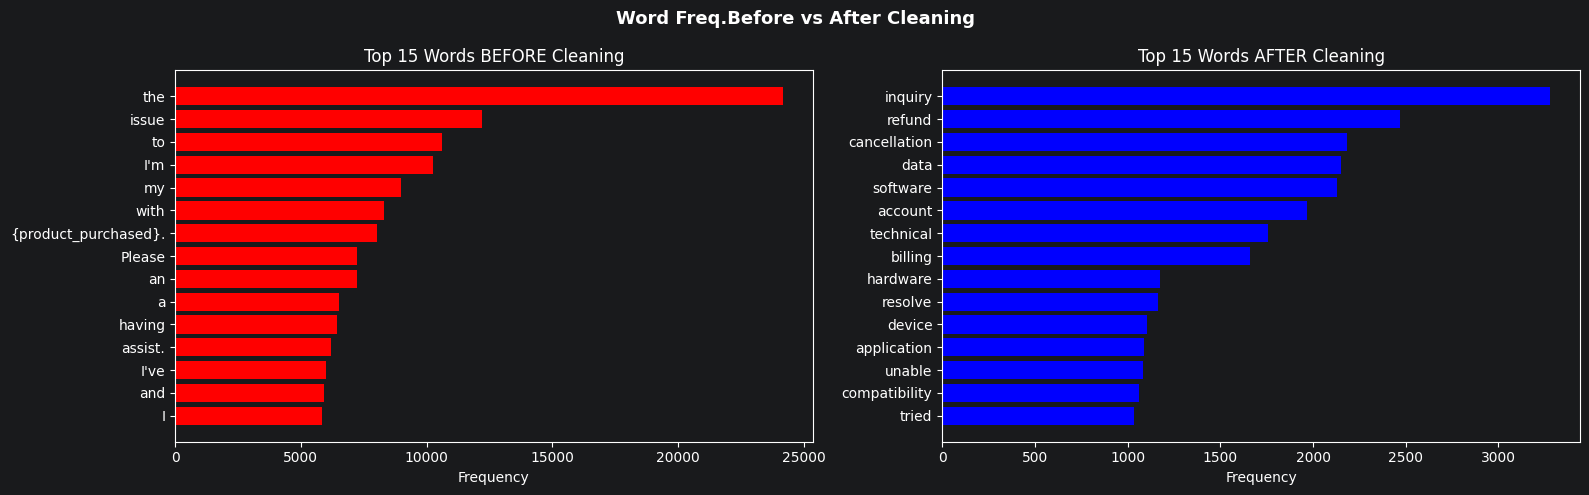

In [3]:
before_freq = Counter(df_raw_list).most_common(15)
after_freq  = Counter(df_cleaned_list).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

words_b, counts_b = zip(*before_freq)
axes[0].barh(words_b, counts_b, color="red")
axes[0].set_title("Top 15 Words BEFORE Cleaning")
axes[0].set_xlabel("Frequency")
axes[0].invert_yaxis()

words_a, counts_a = zip(*after_freq)
axes[1].barh(words_a, counts_a, color="blue")
axes[1].set_title("Top 15 Words AFTER Cleaning")
axes[1].set_xlabel("Frequency")
axes[1].invert_yaxis()

plt.suptitle("Word Freq.Before vs After Cleaning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#### Cleaning Result

After observing the changes in word freqency, the custom stop word removal done in the EDA section is effective in dropping high freqency yet contextually insignificant words.

In [4]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)       # Use unigrams and bigrams
)

X_tfidf = vectorizer.fit_transform(df_cleaned["clean_text"])
print("TF-IDF Matrix Shape:", X_tfidf.shape)

TF-IDF Matrix Shape: (8465, 5000)


In [5]:
# Generate sentence embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(
    df_raw_combined.tolist(),
    show_progress_bar=True,
    batch_size=32
)

print("Embeddings Shape:", embeddings.shape)

# Normalize embeddings
embeddings_normalized = norm(embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

Embeddings Shape: (8469, 384)


In [6]:
mapper_tfidf = umap.UMAP(random_state=0).fit_transform(X_tfidf)
mapper_embedding = umap.UMAP(random_state=0).fit_transform(embeddings_normalized)

E:\EMAT\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
E:\EMAT\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


[900869.625, 550199.0, 395699.4375, 325098.375, 259328.390625, 220918.453125, 185238.046875, 155386.71875, 130060.4765625]
[804957.0, 492926.28125, 354379.125, 275556.90625, 210375.0625, 168471.25, 134299.0, 111104.7890625, 94707.25]


<function matplotlib.pyplot.show(close=None, block=None)>

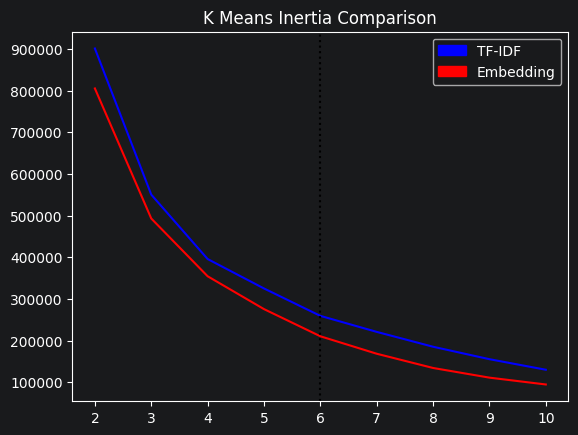

In [7]:
k_range = range(2,11)

tfidf_km_goodness = []
embedd_km_goodness = []


handles = [Patch(color="blue", label="TF-IDF"), Patch(color="red", label="Embedding")]


for k in k_range:
    kmeans_tfidf = KMeans(n_clusters=k, random_state=0, n_init=10)
    # labels_tfidf = kmeans_tfidf.fit_predict(X_tfidf)
    labels_tfidf = kmeans_tfidf.fit_predict(mapper_tfidf)
    tfidf_km_goodness.append(kmeans_tfidf.inertia_)

    kmeans_embedd = KMeans(n_clusters=k, random_state=0, n_init=10)
    # labels_embedd = kmeans_embedd.fit_predict(X_embeddings_normal)
    labels_embedd = kmeans_embedd.fit_predict(mapper_embedding)
    embedd_km_goodness.append(kmeans_embedd.inertia_)

print(tfidf_km_goodness)
print(embedd_km_goodness)

plt.plot(k_range, tfidf_km_goodness, color="blue", label="TF-IDF")
plt.plot(k_range, embedd_km_goodness, color="red", label="embedd")
plt.axvline(x = 6, color = 'black', ls = ':')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(handles=handles)
plt.title("K Means Inertia Comparison")
plt.show

### Result
There is a natural elbow point at k=6 for both the TF-IDF and Embedding Approach. However, the later approach, embeddings, does seem to consistantly produce tighter groupings which is consistant with the results in our pre-limenary EDA

## 2. Hypothesis Creation

Hypothesis 1: The embedding approach, due to it structurally being able to better support synonyms, will lead to tighter and more cohesive groupings.

$$
Null \space  Hypothesis(H_0): Silhouette \space Score \space of \space Embedding \space Approach \space = \space Silhouette \space Score \space of \space TF.IDF \space Approach
$$

$$
Alternative \space  Hypothesis(H_1): Silhouette \space Score \space of \space Embedding \space Approach \space > \space Silhouette \space Score \space of \space TF.IDF \space Approach
$$

### Parameters:
**Test Choice**: Paired T-Test<br>
**Metric**: Silhouette Score<br>
**Confidence Interval(CI)**: 99%<br>

#### General Overview
The paired t-test is used because the experiment will revolve around applying two different vectorization methods on the same corpus, meaning that each of the document vectors can be considered a pairing across these two scenarios. Pre-processing of the corpus will include the removal of digits, and punctuation, and the lemmanization of the result. After which, tf-idf and a word embedding model will be applied to the corpus to create our vector embeddings which will then be passed through PCA. The selection of PCA over other similar dimension reduction algorithms like t-SNE or UMAP is due to its preservation of linearity, as the former two used clustering methods that don't preserve the distancing between clusters. Finally, the Sillouette Scores will be caluclated using the K-Means clustering technique set to 6 clusters as provide by our elbow point.

Note: UMAP can be used to identify the number of clusters within a dataset, so this usage should be fine

#### Pipeline
<center>Pre-Processing => Word Vector Creation Using the Two Approaches => Application of PCA => K-Means Clustering => Accepting or Rejecting Hypothesis </center>

## 3. T-Test Experiment

In [9]:
vectorizer = TfidfVectorizer(max_features = 5000, ngram_range=(1,2))
model = SentenceTransformer("all-MiniLM-L6-v2")

X_tfidf = vectorizer.fit_transform(df_cleaned["clean_text"])
feature_names = vectorizer.get_feature_names_out()

X_embeddings = model.encode(
    df_cleaned["clean_text"].tolist(),
    show_progress_bar=True
)

X_embeddings_normal = norm(X_embeddings)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/265 [00:00<?, ?it/s]

In [10]:
PCA_a = PCA(n_components=50)
tf_idf_redux = PCA_a.fit_transform(X_tfidf)

PCA_b = PCA(n_components=50)
embedding_redux = PCA_b.fit_transform(X_embeddings_normal)

In [11]:
kmeans_tfidf = KMeans(n_clusters=6, random_state=0)
tfidf_labels = kmeans_tfidf.fit_predict(tf_idf_redux)
tfidf_sill = silhouette_samples(tf_idf_redux, tfidf_labels)

kmeans_embedding = KMeans(n_clusters=6, random_state=0)
embedding_labels = kmeans_embedding.fit_predict(embedding_redux)
embedding_sill = silhouette_samples(embedding_redux, embedding_labels)

In [12]:
stats.ttest_rel(tfidf_sill,embedding_sill)

TtestResult(statistic=np.float64(-0.4582486751771129), pvalue=np.float64(0.6467855580082614), df=np.int64(8464))

## 4. Results

Our t-test's result show that we easily clear the p = 0.01 threshold to reject our null hypothesis.

Recommendation tracks with initial EDA findings that embeddings provide more distinct data clustering patterns. However, it be stated that the interprability of the clusters themselves will have to be tested in the next step using methods like topic modeling to extract the contents of each of the clusters.

C:\Users\wzh20\AppData\Local\Temp\ipykernel_13732\934202178.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tfidf_sill, embedding_sill], labels=['TF-IDF', 'Embeddings'])


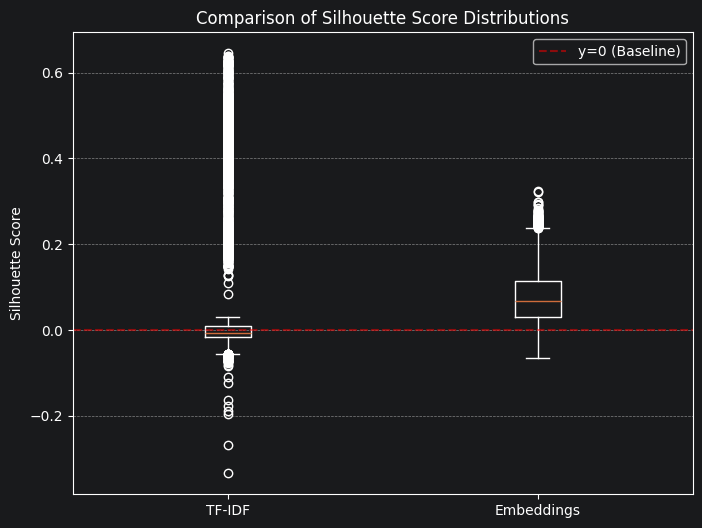

In [13]:
plt.figure(figsize=(8, 6))
plt.boxplot([tfidf_sill, embedding_sill], labels=['TF-IDF', 'Embeddings'])
plt.title('Comparison of Silhouette Score Distributions')
plt.ylabel('Silhouette Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='y=0 (Baseline)')
plt.legend()
plt.show()


In [14]:
mean_tfidf = np.mean(tfidf_sill)
std_tfidf = np.std(tfidf_sill)
mean_emb = np.mean(embedding_sill)
std_emb = np.std(embedding_sill)

print(f"TF-IDF: mean = {mean_tfidf:.3f}, std = {std_tfidf:.3f}")
print(f"Embeddings: mean = {mean_emb:.3f}, std = {std_emb:.3f}")

TF-IDF: mean = 0.076, std = 0.180
Embeddings: mean = 0.077, std = 0.066


C:\Users\wzh20\AppData\Local\Temp\ipykernel_13732\1631961195.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tfidf_sill, embedding_sill], labels=['TF-IDF', 'Embeddings'])


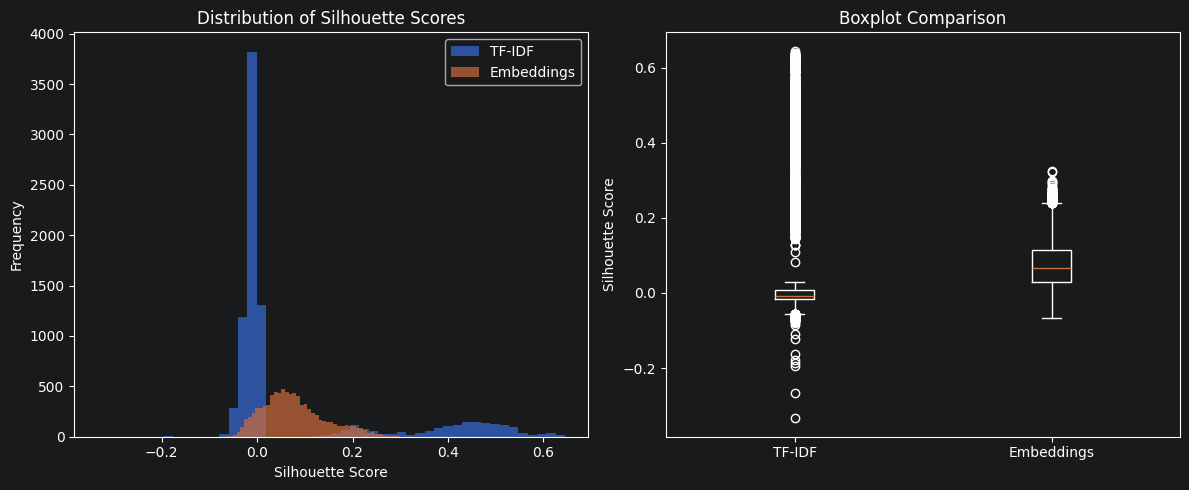

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(tfidf_sill, bins=50, alpha=0.7, label='TF-IDF')
plt.hist(embedding_sill, bins=50, alpha=0.7, label='Embeddings')
plt.legend()
plt.title('Distribution of Silhouette Scores')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.subplot(1,2,2)
plt.boxplot([tfidf_sill, embedding_sill], labels=['TF-IDF', 'Embeddings'])
plt.title('Boxplot Comparison')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()